<a href="https://colab.research.google.com/github/yeshaa23/Project-A-Kelompok-4-Pertamina-PBAGenap/blob/main/Week_5_PBA_POS_Tagging_Pertamina.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#POS (part-of-speech)

Part-of-speech (POS) tagging is the process of assigning a part-of-speech tag (Noun, Verb, Adjective...) to each word in an input text.

In [ ]:
# ── STEP 0: Install Stanza ────────────────────────────────────
!pip install -q stanza pandas matplotlib nltk

import stanza
stanza.download("id")  # download model Bahasa Indonesia
nlp = stanza.Pipeline("id", processors="tokenize,pos")

import pandas as pd
import re
import nltk
import matplotlib.pyplot as plt

nltk.download("stopwords", quiet=True)
from nltk.corpus import stopwords
stop_words = set(stopwords.words("indonesian"))

In [69]:
# ── STEP 1–2: Baca Excel dari lokal (Google Colab) ─────────────
from google.colab import files

uploaded = files.upload()  # akan muncul tombol "Choose Files"

import io
filename = list(uploaded.keys())[0]
df = pd.read_excel(io.BytesIO(uploaded[filename]))  # ← ganti read_csv → read_excel

df = df.dropna(subset=["Konten"]).reset_index(drop=True)
print("Shape:", df.shape)
print("Kolom:", df.columns.tolist())

Saving artikel_manual_pertamina (1).xlsx to artikel_manual_pertamina (1) (2).xlsx
Shape: (50, 9)
Kolom: ['Case ID', 'Case', 'Newsroom', 'Tanggal', 'Judul', 'Konten', 'Link', 'Tag', 'Tone']


In [70]:
df.head()

,Case ID,Case,Newsroom,Tanggal,Judul,Konten,Link,Tag,Tone
0,NaN,NaN,ylki.or.id,2016-06-08 00:00:00,Siaran Pers YLKI : Mendesak PT Pertamina untuk...,Kejadian kecurangan takaran pada SPBU yang ter...,https://ylki.or.id/siaran-pers-ylki-mendesak-p...,Hukum,Negatif
1,NaN,NaN,Kompas.com,6 Juli 2017,Pertamina Kembangkan Program Non-Tunai Pembeli...,"PONTIANAK, KOMPAS.com - PT Pertamina mensosial...",https://money.kompas.com/read/2017/07/06/14535...,BBM,Netral
2,NaN,NaN,Kompas.com,14 Desember 2017,"Pertamina Tak Masalahkan Nama Pertamini, tapi...","Nusa Dua, KompasOtomotif - Keberadaan kios-kio...",https://otomotif.kompas.com/read/2017/12/14/15...,Bisnis,Positif
3,NaN,NaN,Kompas.com,27 Juli 2017,Pertamina Patra Niaga Akan Bangun SPBU Skala U...,"JAKARTA, KOMPAS.com - PT Pertamina Patra Niaga...",https://money.kompas.com/read/2017/07/27/17565...,Bisnis,Positif
4,NaN,NaN,Kompas.com,18 Maret 2026,"Gaji Manajer 'Engineering' Chevron Rp 51,25 Ju...","JAKARTA, KOMPAS.com - Situs pencari kerja, Job...",https://money.kompas.com/read/2016/03/18/14152...,Bisnis,Negatif


In [71]:
# ── STEP 3: Preprocessing ────────────────────────────────────
def preprocess(text):
    text = str(text).lower()
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"[^\w\s]", " ", text)
    text = re.sub(r"\d+", "", text)
    text = re.sub(r"\s+", " ", text).strip()
    tokens = [t for t in text.split() if t not in stop_words]
    return " ".join(tokens)

df["Konten_clean"] = df["Konten"].apply(preprocess)

In [72]:
# ── STEP 4–5: Tokenisasi + POS Tagging (Stanza) ──────────────
all_pos = []

for idx, row in df.iterrows():
    teks = row["Konten_clean"]
    doc_pos = nlp(teks)  # Stanza pipeline

    print(f"\n{'='*40}")
    print(f"Dokumen {idx}: {str(row['Judul'])[:60]}")
    print(f"{'='*40}")
    print("{:<16}{}".format("Word", "POS Tag"))
    print("-" * 30)

    for sentence in doc_pos.sentences:
        for token in sentence.words:
            word = token.text
            tag  = token.upos   # Universal POS tag (NOUN, VERB, ADJ, dll.)
            print(u"{:<16}{:>2}".format(word, tag))
            all_pos.append({
                "doc_id"  : idx,
                "Judul"   : row["Judul"],
                "Kata"    : word,
                "POS Tag" : tag
            })

Streaming output truncated to the last 5000 lines.
tujuh           NUM
energi          NOUN
bersih          NOUN
terjangkau      ADJ
poin            NOUN
penanggulangan  NOUN
perubahan       NOUN
iklim           NOUN
pilar           NOUN
program         NOUN
seb             NOUN
energizing      NOUN
sustainable      X
community        X
meliputi        VERB
kegiatan        NOUN
edukasi         NOUN
sharing         NOUN
session         NOUN
perwira         NOUN
pertamina       NOUN
class            X
inovasi         NOUN
pemasangan      NOUN
solar           NOUN
panel           NOUN
keterlibatan    NOUN
komunitas       NOUN
upcycling       NOUN
competition      X
and              X
expo             X
kesempatan      NOUN
asisten         NOUN
pemerintahan    NOUN
kesejahteraan   NOUN
rakyat          NOUN
kesra           NOUN
dumai           NOUN
yusrizal        NOUN
program         NOUN
seb             NOUN
berperan        VERB
mendukung       NOUN
pemerintah      NOUN
menciptakan     VE

In [73]:
# ── STEP 6: Simpan ke DataFrame ─────────────────────────────
df_pos = pd.DataFrame(all_pos)
print(f"\nTotal token: {len(df_pos)}")


Total token: 11142


In [74]:
# ── STEP 7: Format kata | POS tag ────────────────────────────
print("\n=== FORMAT: Kata | POS Tag ===")
print(df_pos[["Kata", "POS Tag"]].to_string(index=False))


=== FORMAT: Kata | POS Tag ===
                 Kata POS Tag
             kejadian    NOUN
           kecurangan    NOUN
              takaran    NOUN
                 spbu    NOUN
               rempoa    NOUN
              ciputat    NOUN
            sesungguh    NOUN
                  nya     DET
                modus    NOUN
             operandi    NOUN
            pengelola    NOUN
                 spbu    NOUN
        mengakibatkan    VERB
             kerugian    NOUN
             konsumen    NOUN
             february    NOUN
                 ylki    NOUN
            informasi    NOUN
             direktur    NOUN
             jenderal    NOUN
         perlindungan    NOUN
             konsumen    NOUN
          berdasarkan     ADP
             pantauan    NOUN
                  bph    NOUN
                migas    NOUN
                 spbu    NOUN
              wilayah    NOUN
             sumatera   PROPN
                   yg    PRON
           kecurangan    NOUN
        

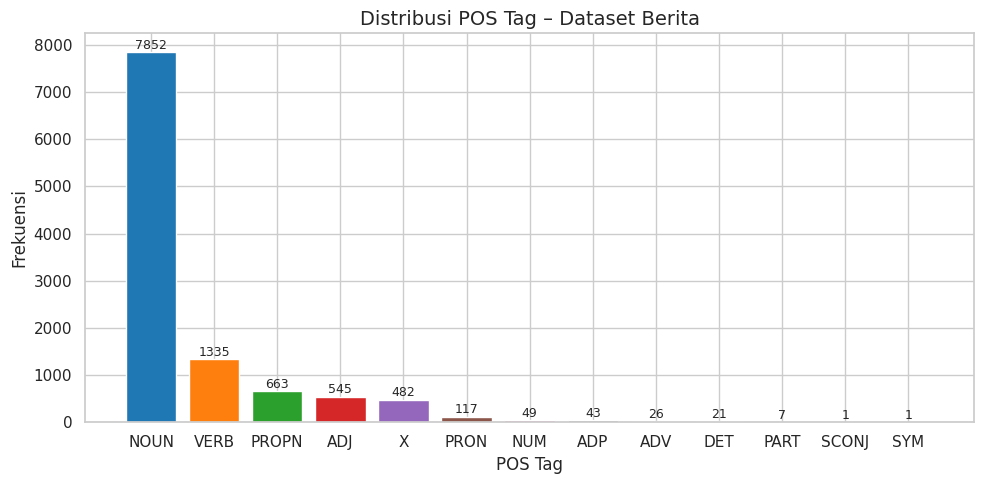

In [75]:
# ── BONUS: Visualisasi ───────────────────────────────────────
pos_counts = df_pos["POS Tag"].value_counts()

plt.figure(figsize=(10, 5))
bars = plt.bar(pos_counts.index, pos_counts.values,
               color=plt.cm.tab10.colors[:len(pos_counts)])
plt.title("Distribusi POS Tag – Dataset Berita", fontsize=14)
plt.xlabel("POS Tag")
plt.ylabel("Frekuensi")
for bar, val in zip(bars, pos_counts.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
             str(val), ha="center", va="bottom", fontsize=9)
plt.tight_layout()
plt.savefig("pos_distribution.png", dpi=150)
plt.show()

In [82]:
# ── Simpan ke CSV ────────────────────────────────────────────
df_pos.to_excel("pertamina_hasil_pos_tagging.xlsx", index=False)
print("\nHasil disimpan ke: pertamina_hasil_pos_tagging.xlsx")


Hasil disimpan ke: pertamina_hasil_pos_tagging.xlsx


Text Embedding

In [ ]:
pip install transformers torch scikit-learn

In [77]:
import pandas as pd
import torch
from transformers import AutoTokenizer, AutoModel
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import classification_report

In [78]:
# normalisasi label
df["Tone"] = df["Tone"].astype(str).str.lower().str.strip()

# teks
texts = df["Konten"].astype(str)
labels = df["Tone"]

In [ ]:
tokenizer = AutoTokenizer.from_pretrained("indobenchmark/indobert-base-p1")
model_bert = AutoModel.from_pretrained("indobenchmark/indobert-base-p1")

In [83]:
def get_embedding(text):
    inputs = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        padding=True,
        max_length=128
    )

    with torch.no_grad():
        outputs = model_bert(**inputs)

    # ambil CLS token
    embedding = outputs.last_hidden_state[:, 0, :]
    return embedding.squeeze().numpy()

In [84]:
X = []

for i, text in enumerate(texts):
    emb = get_embedding(text)
    X.append(emb)

    if i % 10 == 0:
        print(f"Progress: {i}/{len(texts)}")

X = pd.DataFrame(X)
y = labels

Progress: 0/50
Progress: 10/50
Progress: 20/50
Progress: 30/50
Progress: 40/50


In [85]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [86]:
from sklearn.svm import SVC

model_svm = SVC(
    kernel='linear',
    class_weight='balanced'  # penting untuk data tidak seimbang
)

model_svm.fit(X_train, y_train)

SVC(class_weight='balanced', kernel='linear')

In [87]:
from sklearn.metrics import classification_report

y_pred = model_svm.predict(X_test)

print("\nHASIL EVALUASI:\n")
print(classification_report(y_test, y_pred, zero_division=0))


HASIL EVALUASI:

              precision    recall  f1-score   support

     negatif       0.50      0.50      0.50         4
      netral       0.00      0.00      0.00         1
     positif       0.67      0.80      0.73         5

    accuracy                           0.60        10
   macro avg       0.39      0.43      0.41        10
weighted avg       0.53      0.60      0.56        10



Meskipun telah digunakan teknik penyeimbangan data seperti stratified split dan class weighting, model tetap gagal mengklasifikasikan kelas netral karena jumlah data yang sangat terbatas (50).

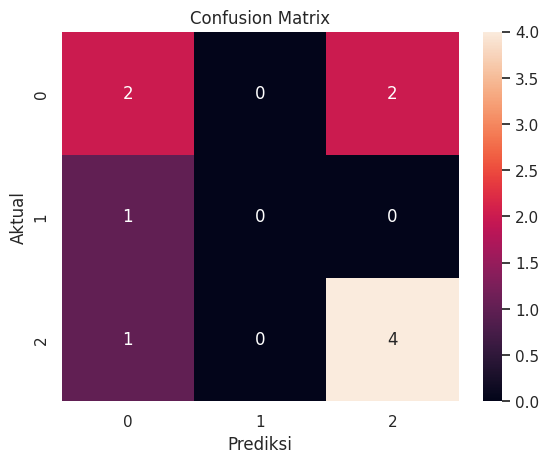

In [88]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Prediksi")
plt.ylabel("Aktual")
plt.title("Confusion Matrix")
plt.show()